In [1]:
from __future__ import print_function

import numpy as np
import yt
import unyt
from yt.units import *
from yt import YTArray
import argparse
import os
import glob
import sys
from astropy.table import Table
from astropy.io import ascii
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import random
from scipy import interpolate
from scipy.signal import correlate2d
#from photutils import detect_threshold, detect_sources, source_properties, EllipticalAperture
from scipy.interpolate import InterpolatedUnivariateSpline as IUS
from scipy.stats import binned_statistic
from scipy.optimize import minimize
import trident
import ast
#import emcee
import numpy.random as rn
from multiprocessing import Pool
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
from yt.units import kpc, cm
import cmasher as cmr
from itertools import combinations
import builtins
from scipy.optimize import curve_fit
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u


# These imports are FOGGIE-specific files
from foggie.utils.consistency import *
from foggie.utils.get_refine_box import get_refine_box
from foggie.utils.get_halo_center import get_halo_center
from foggie.utils.get_proper_box_size import get_proper_box_size
from foggie.utils.get_run_loc_etc import get_run_loc_etc
from foggie.utils.yt_fields import *
from foggie.utils.foggie_load import *
from foggie.utils.analysis_utils import *

# These imports for datashader plots
import datashader as dshader
from datashader.utils import export_image
import datashader.transfer_functions as tf
import pandas as pd
import matplotlib as mpl
import h5py
import matplotlib.cm as mtcm
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D


import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np
import os

from mpl_toolkits.mplot3d.art3d import Line3DCollection

from foggie.clumps.clump_finder.utils_diskproject import load_disk 
from collections import defaultdict
import pandas as pd
import math
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable


from foggie.clumps.clump_finder.utils_clump_finder import *
from foggie.clumps.clump_finder.clump_finder_argparser import *
from foggie.clumps.clump_finder.fill_topology import *
from foggie.clumps.clump_finder.clump_load import *
from foggie.clumps.clump_finder.clump_finder import clump_finder



In [2]:
def generate_foggie_paths(halo, run, snap):
    # Define base paths
    foggie_base_dir = "/Users/vidasaeedzadeh/Projects/foggie_data/"
    code_base_path = "/Users/vidasaeedzadeh/Projects/repositories/foggie/foggie/"
    output_base_dir = "/Users/vidasaeedzadeh/Projects/foggie_outputs/"

    # Zero-pad the halo number to 6 digits
    halo_number = halo.zfill(6)

    # Define directory and file paths dynamically
    foggie_dir = os.path.join(foggie_base_dir, f"halo_{halo_number}", run + '/')
    snap_name = os.path.join(foggie_dir, snap, snap)
    halo_c_v_name = os.path.join(code_base_path, f"halo_infos/{halo_number}/{run}/halo_c_v")
    trackname = os.path.join(code_base_path, f"halo_tracks/{halo_number}/nref11n_selfshield_15/halo_track_200kpc_nref9")

    # Output directory (adjust based on needs)
    output_dir = output_base_dir

    # Return paths
    return foggie_dir,code_base_path, snap_name, halo_c_v_name, trackname, output_dir

# specify halo and snapshot
run = 'nref11c_nref9f'

ions = ['HI','OVI', 'CIV', 'SiIV', 'CIII', 'SiIII', 'MgII', 'SiII']
orientations = ['face','edge']
regions = ['all','cgm'] 
cmap = mtcm.get_cmap('Set1', len(ions))  

box_name = '100'
output = 'RD0032'
snap = output
resolutions = [0.27,1,3,6]
if snap == 'RD0042':
    halos = ['2392','4123','5016','5036','8508']
    z = '0.0'
elif snap == 'RD0040':
    halos = ['2878','2392','4123','5016','5036','8508']
    z = '0.1'
elif snap == 'RD0032':
    halos = ['2878','2392','4123','5016','5036','8508']
    z = '0.5'

unit_system = 'photons'

log_vals = [100,200,300,400,500,1000,2000,3000,4000]#1,10,25,50,75,

flux_thresholds = {
    'HI': list(log_vals),
    'CII': list(log_vals),
    'CIII': list(log_vals),
    'CIV': list(log_vals),
    'OVI': list(log_vals),
    'MgII': list(log_vals),
    'SiII': list(log_vals),
    'SiIII': list(log_vals),
    'SiIV': list(log_vals)}

    

/var/folders/03/8m_yf9p11xd_2mlw7w_4dw4w0000gn/T/ipykernel_45677/229755489.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mtcm.get_cmap('Set1', len(ions))


Table 3

In [4]:
# 1. Unit coversion: converting spatial resolution from arcsec to kpc

def spatial_resolution(theta_arcsec, z):
    """
    Convert angular resolution (arcsec) at redshift z
    into physical scale (kpc).
    
    Parameters
    ----------
    theta_arcsec : float
        Angular resolution in arcseconds.
    z : float
        Target redshift.
    
    Returns
    -------
    float
        Physical resolution in kpc.
    """
    # Angular diameter distance in kpc
    DA = cosmo.angular_diameter_distance(z).to(u.kpc).value
    
    # Convert arcsec to radians
    theta_rad = theta_arcsec * (np.pi / 648000.0)
    
    # Physical size in kpc
    return theta_rad * DA




In [5]:
print(np.round(spatial_resolution(0.03, 2), 2),"kpc")

0.26 kpc


In [6]:
# convert velocity to R
def velocity_to_R(delta_v_kms):
    """
    Convert spectral resolution from velocity units (km/s) 
    to resolving power R.
    
    Parameters
    ----------
    delta_v_kms : float or list of floats
        Spectral resolution in km/s.
        
    Returns
    -------
    float or list of floats
        Resolving power R.
    """
    c = 299792.458  # speed of light in km/s
    if isinstance(delta_v_kms, (list, tuple)):
        return [c / dv for dv in delta_v_kms]
    else:
        return c / delta_v_kms

In [7]:
delta_v_kms = 400
velocity_to_R(delta_v_kms)

749.481145

In [8]:
# converting surface brightness from erg/s/cm^2/arcsec^2 to photons/s/cm^2/sr following equation: 

def sb_to_photons(f_lambda, wavelength_A):
    """
    Convert surface brightness from erg/s/cm^2/arcsec^2 
    to photons/s/cm^2/sr at a given wavelength.
    
    Parameters
    ----------
    f_lambda : float
        Surface brightness in erg/s/cm^2/arcsec^2
    wavelength_A : float
        Wavelength in Angstroms (Å)
        
    Returns
    -------
    float
        Photon surface brightness in photons/s/cm^2/sr
    """
    # constants
    h = 6.62607015e-27  # erg*s
    c = 2.99792458e10   # cm/s
    
    # energy per photon
    wavelength_cm = wavelength_A * 1e-8
    E_photon = h * c / wavelength_cm
    
    # convert arcsec^2 -> sr
    arcsec2_to_sr = (np.pi / (180.0 * 3600.0))**2 # = 1 / 4.25e10
    
    # convert SB to erg/s/cm^2/sr
    sb_erg_sr = f_lambda / arcsec2_to_sr
    
    # photons
    f_LU = sb_erg_sr / E_photon
    return f_LU

In [9]:
# Example: OVI Hayes et al 2016 detection 1032 Å, SB = 1e-17 erg/s/cm^2/arcsec^2
sb_limit = 2e-19
wavelength = 6563  # Å
print(sb_to_photons(sb_limit, wavelength), "photons cm^-2 s^-1 sr^-1")

2811.29185221697 photons cm^-2 s^-1 sr^-1


In [10]:
# Converting surface brightness limits between exposure times

def sb_scale(sb_ref, t_ref_hr, t_new_hr):
    """
    Scale a surface-brightness (SB) limit between exposure times assuming background-limited regime:
        SB = 1/sqrt(t)
        SB_new/SB_ref = sqrt(t_ref / t_new)
        SB_new = SB_ref * sqrt(t_ref / t_new)

    Parameters
    ----------
    sb_ref : float
        Reference SB limit in erg/s/cm^2/arcsec^2.
    t_ref_hr : float
        Reference exposure time in hours.
    t_new_hr : float or array-like
        New exposure time(s) in hours.

    Returns
    -------
    float or np.ndarray
        Scaled SB limit(s) in erg/s/cm^2/arcsec^2.
    """
    t_new_hr = np.asarray(t_new_hr, dtype=float)
    return sb_ref * np.sqrt(t_ref_hr / t_new_hr)


def convert_sb_erg_to_ph(sb_ref_erg_arcsec2, t_ref_hr, t_list_hr, wavelength_A):
    """
    scale an SB limit from a reference exposure time to a list of new exposure times
    and convert each to photons/s/cm^2/sr at the given wavelength.

    Returns a dict with both erg and photon units.
    """
    t_list_hr = np.atleast_1d(t_list_hr).astype(float)
    sb_scaled_erg = sb_scale(sb_ref_erg_arcsec2, t_ref_hr, t_list_hr)
    sb_scaled_phot = sb_to_photons(sb_scaled_erg, wavelength_A)
    return {
        "exposures_hr": t_list_hr,
        "sb_erg_arcsec2": sb_scaled_erg,
        "sb_photons_sr": sb_scaled_phot,
    }

def convert_sb_ph(sb_ref_erg_arcsec2, t_ref_hr, t_list_hr):
    """
    scale an SB limit from a reference exposure time to a list of new exposure times

    Returns a dict in photon units.
    """
    t_list_hr = np.atleast_1d(t_list_hr).astype(float)
    sb_scaled_ph = sb_scale(sb_ref_erg_arcsec2, t_ref_hr, t_list_hr)
    
    return {
        "exposures_hr": t_list_hr,
        "sb_photons_sr": sb_scaled_ph,
    }#




In [11]:
# ---- Example: MAGPIE, O VI 1032 Å ----
# Given: SB_ref = 3e-19 erg/s/cm^2/arcsec^2 at t_ref = 41.7 hr
example = convert_sb_erg_to_ph(
    sb_ref_erg_arcsec2=1e-17,
    t_ref_hr=2,
    t_list_hr=[10, 100],
    wavelength_A=3727
)

for t, sb_erg, sb_ph in zip(example["exposures_hr"], example["sb_erg_arcsec2"], example["sb_photons_sr"]):
    print(f"Exposure = {t:6.1f} hr | SB = {sb_erg:.3e} erg/s/cm^2/arcsec^2 | "
          f"{sb_ph:7.1f} photons/s/cm^2/sr (OVI 1032 Å)")

Exposure =   10.0 hr | SB = 4.472e-18 erg/s/cm^2/arcsec^2 | 35698.3 photons/s/cm^2/sr (OVI 1032 Å)
Exposure =  100.0 hr | SB = 1.414e-18 erg/s/cm^2/arcsec^2 | 11288.8 photons/s/cm^2/sr (OVI 1032 Å)


In [12]:
# ---- Example: MAGPIE, O VI 1032 Å ----
# Given: SB_ref = 625 photons at t_ref = 41.7 hr

example = convert_sb_ph(
    sb_ref_erg_arcsec2=160,
    t_ref_hr=10,
    t_list_hr=[10, 100]
)

for t, sb_ph in zip(example["exposures_hr"], example["sb_photons_sr"]):
    print(f"Exposure = {t:6.1f} hr | "
          f"{sb_ph:7.1f} photons/s/cm^2/sr ( Å)")
    

Exposure =   10.0 hr |   160.0 photons/s/cm^2/sr ( Å)
Exposure =  100.0 hr |    50.6 photons/s/cm^2/sr ( Å)


Figure 15

/var/folders/03/8m_yf9p11xd_2mlw7w_4dw4w0000gn/T/ipykernel_45677/2409572673.py:346: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(right=0.88)


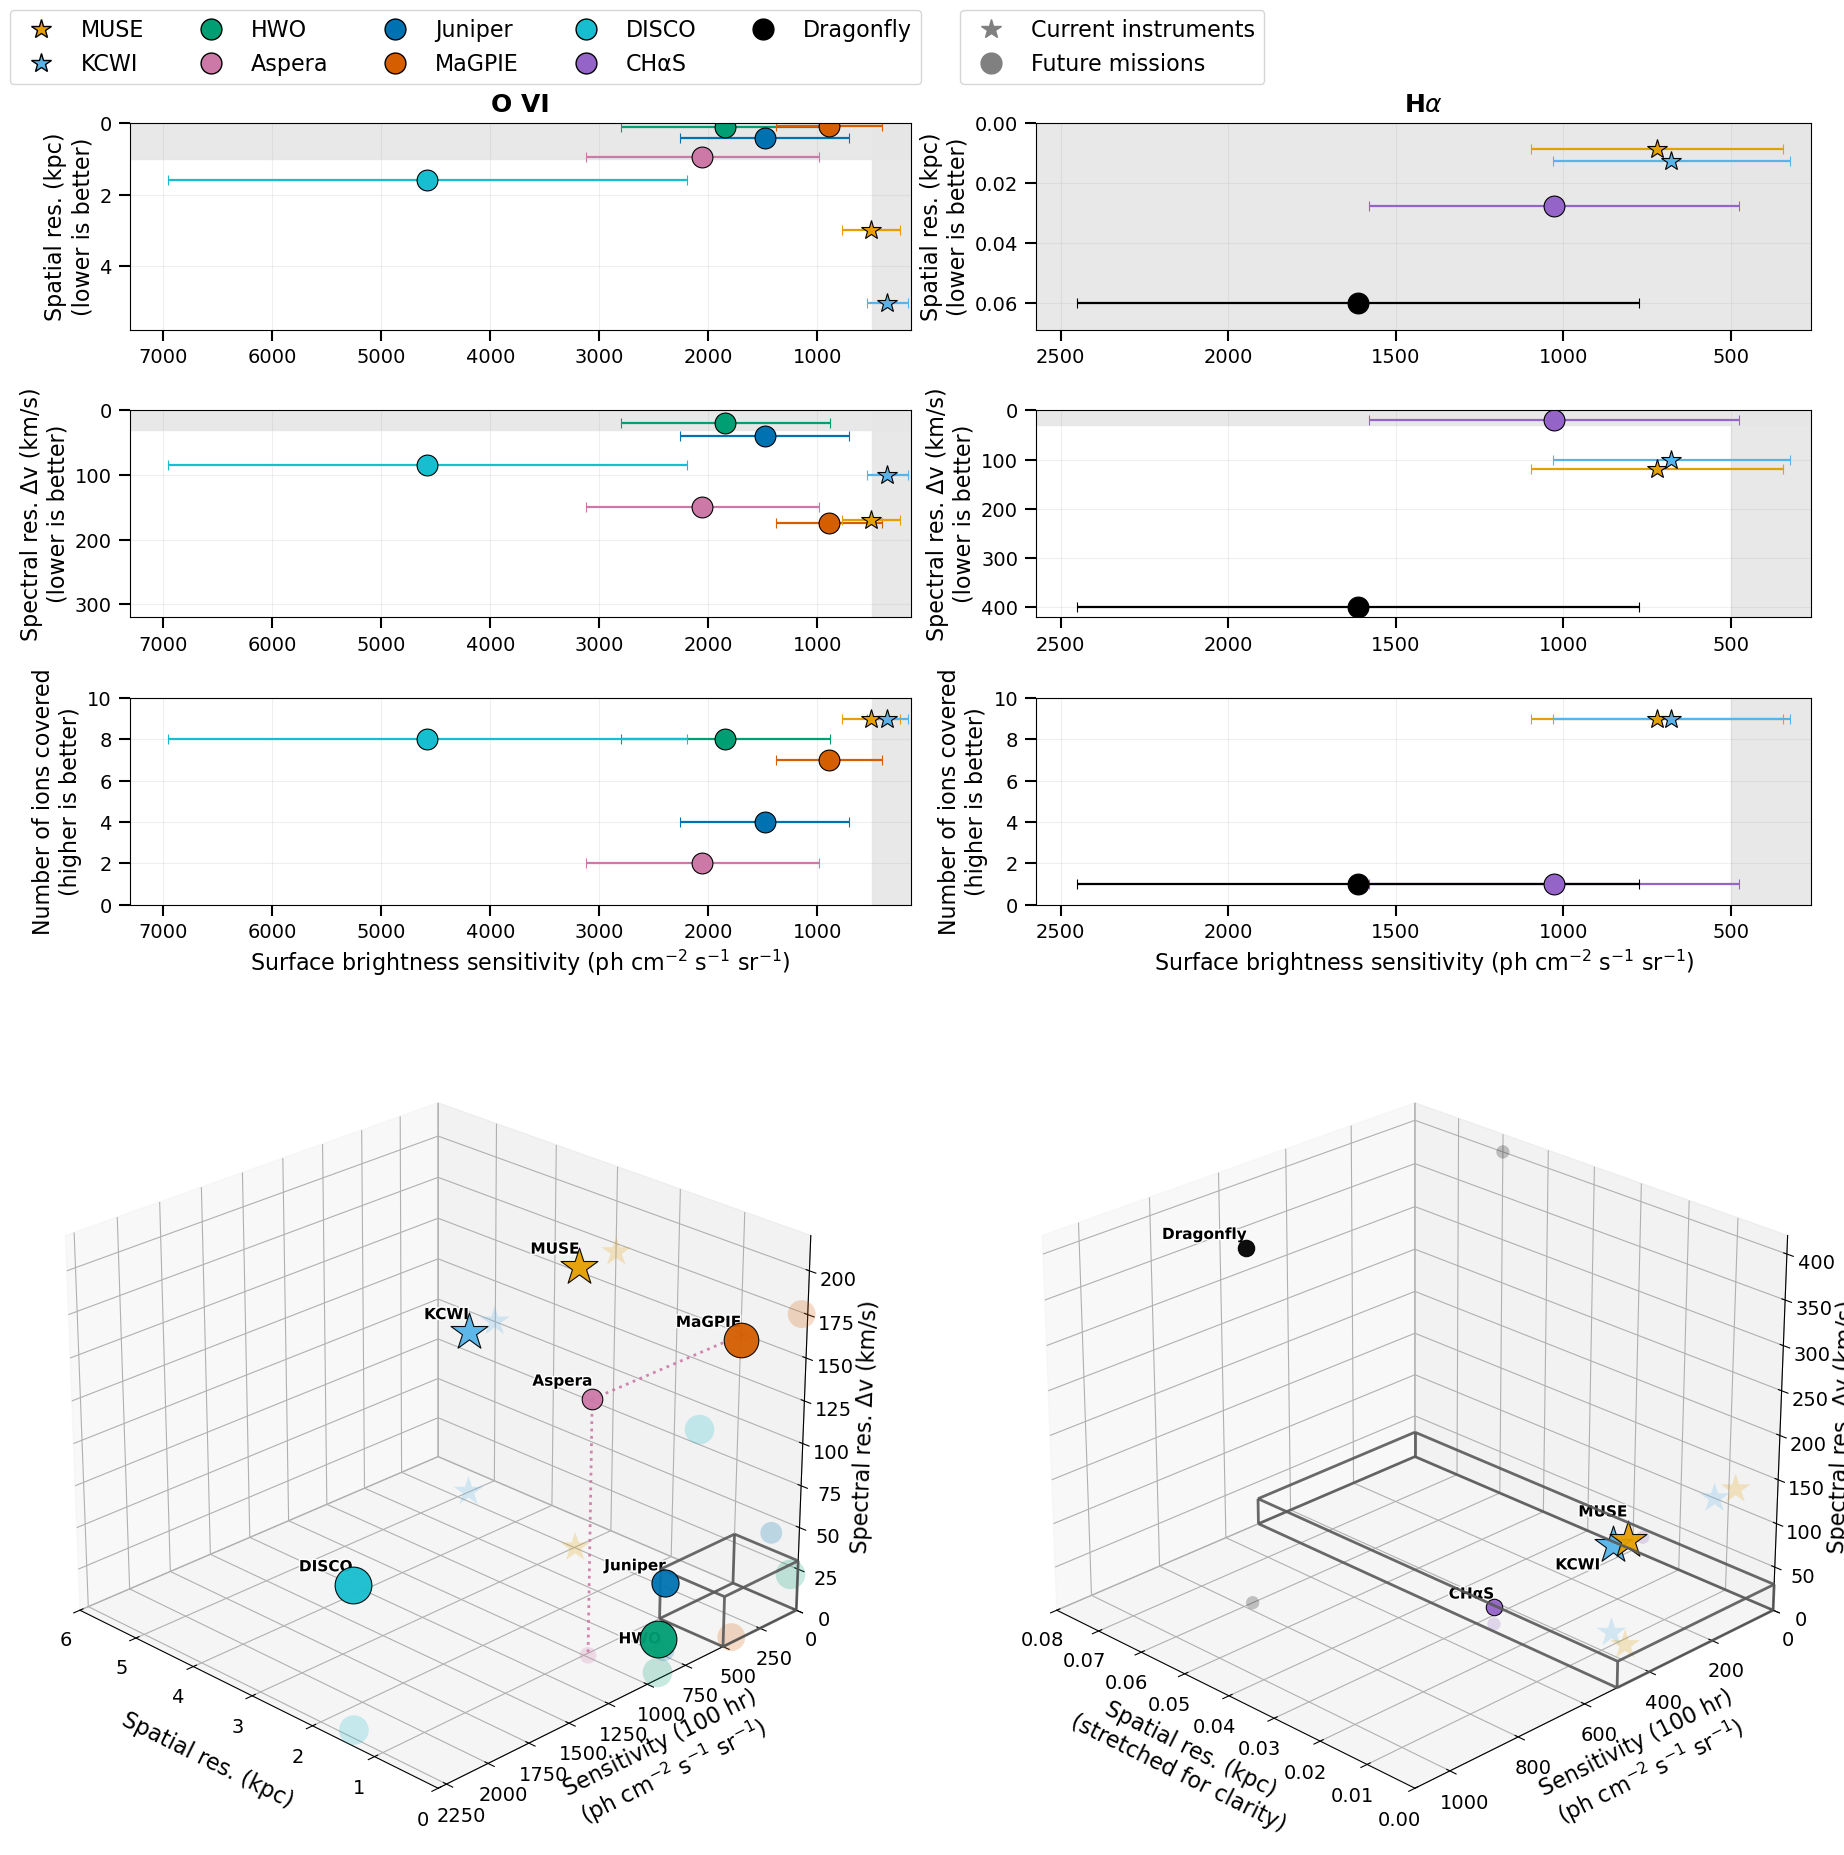

Saved: /Users/vidasaeedzadeh/Projects/foggie_outputs/All_halos/Conclusion/instrument_space_side_by_side_OVI_Ha_Nions.png


In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe
import pandas as pd
import numpy as np
import os

wong_colors = [
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # green
    "#CC79A7",  # pink/purple
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#17BECF",  # cyan
    "#9464C8",  # dark purple
    "#000000",  # black
]

# All instruments in a fixed order for consistent color assignment
all_instruments_ordered = [
    "MUSE",
    "KCWI", 
    "HWO",
    "Aspera",
    "Juniper",
    "MaGPIE",
    "DISCO",
    "CHαS",
    "Dragonfly",
]

instr2color = {inst: wong_colors[i] for i, inst in enumerate(all_instruments_ordered)}



def add_corner_wireframe(ax, x1=1.0, y1=500.0, z1=30.0, color='0.35', lw=2.0, dash=True):
    e = []
    e += [((0,0,0),(x1,0,0)), ((0,y1,0),(x1,y1,0)),
          ((0,0,z1),(x1,0,z1)), ((0,y1,z1),(x1,y1,z1))]
    e += [((0,0,0),(0,y1,0)), ((x1,0,0),(x1,y1,0)),
          ((0,0,z1),(0,y1,z1)), ((x1,0,z1),(x1,y1,z1))]
    e += [((0,0,0),(0,0,z1)), ((x1,0,0),(x1,0,z1)),
          ((0,y1,0),(0,y1,z1)), ((x1,y1,0),(x1,y1,z1))]
    ls = (0, (4, 3)) if dash else 'solid'
    lc = Line3DCollection(e, colors=color, linewidths=lw, linestyles=ls, alpha=0.9)
    ax.add_collection3d(lc)

def mid_min_max(lo, hi):
    lo, hi = float(lo), float(hi)
    return 0.5*(lo+hi), lo, hi

def sens_mid_err(row):
    xm, lo, hi = mid_min_max(row["Sensitivity_100hr"], row["Sensitivity_10hr"])
    return xm, np.array([[xm - lo], [hi - xm]])

def spec_mid_err(row):
    ym, lo, hi = mid_min_max(row["Dv_min"], row["Dv_max"])
    return ym, np.array([[ym - lo], [hi - ym]])

def build_df(rows):
    """
    rows: list of tuples
      (Instrument, spatial_kpc, dv_min, dv_max, sb_10hr, sb_100hr, n_ions)
    """
    return pd.DataFrame({
        "Instrument":        [r[0] for r in rows],
        "Spatial_kpc":        [r[1] for r in rows],
        "Dv_min":             [r[2] for r in rows],
        "Dv_max":             [r[3] for r in rows],
        "Sensitivity_10hr":   [r[4] for r in rows],
        "Sensitivity_100hr":  [r[5] for r in rows],
        "Nions":              [r[6] for r in rows],
    })

def shape_for(inst, current):
    return '*' if inst in current else 'o'

def plot_column(fig, gs_cell, df, title, current, instr2color, label_offsets=None,
                xlim=None, shade_x=500, shade_yA=1.0, shade_yB=30.0):
    if label_offsets is None:
        label_offsets = {}

    # Top: 3 stacked 2D
    gs_top = gs_cell.subgridspec(3, 1, hspace=0.06)
    axA = fig.add_subplot(gs_top[0, 0])
    axB = fig.add_subplot(gs_top[1, 0], sharex=axA)
    axC = fig.add_subplot(gs_top[2, 0], sharex=axA)

    # X limits from data if not given
    XMIN = float(builtins.min(df["Sensitivity_100hr"].min(), df["Sensitivity_10hr"].min()) * 0.8)
    XMAX = float(builtins.max(df["Sensitivity_100hr"].max(), df["Sensitivity_10hr"].max()) * 1.05)
    if xlim is None:
        xlim = (XMIN, XMAX)

    SHADE = dict(color='0.9', alpha=0.9, zorder=0)

    # --- Panel A: Spatial vs Sensitivity
    axA.set_title(title, fontsize=18, pad=8,weight='bold')
    axA.set_ylabel("Spatial res. (kpc)\n(lower is better)", fontsize=16)
    axA.set_xlim(*xlim); axA.invert_xaxis()
    ymax = df["Spatial_kpc"].max()
    axA.set_ylim(0, ymax * 1.15)
    #axA.set_ylim(0, max(0.01, float(df["Spatial_kpc"].max()) + 0.5)); 
    axA.invert_yaxis()
    axA.grid(True, alpha=0.2)
    axA.axvspan(xlim[0], shade_x, **SHADE)
    axA.axhspan(0, shade_yA, **SHADE)

    for _, r in df.iterrows():
        inst = r["Instrument"]
        col = instr2color[inst]
        m = shape_for(inst, current)
        xmid, xerr = sens_mid_err(r)
        y = float(r["Spatial_kpc"])
        axA.errorbar(xmid, y, xerr=xerr, yerr=None, fmt=m, ms=15, color=col, ecolor=col,
                     elinewidth=1.6, capsize=3.5, mec='k', mew=0.8)

    # --- Panel B: Spectral vs Sensitivity
    axB.set_ylabel("Spectral res. Δv (km/s)\n(lower is better)", fontsize=16)
    axB.set_xlim(*xlim); axB.invert_xaxis()
    axB.set_ylim(0, max(320.0, float(df["Dv_max"].max()) * 1.05)); axB.invert_yaxis()
    axB.grid(True, alpha=0.2)
    axB.axvspan(xlim[0], shade_x, **SHADE)
    axB.axhspan(0, shade_yB, **SHADE)

    for _, r in df.iterrows():
        inst = r["Instrument"]
        col = instr2color[inst]
        m = shape_for(inst, current)
        xmid, xerr = sens_mid_err(r)
        ymid, yerr = spec_mid_err(r)
        axB.errorbar(xmid, ymid, xerr=xerr, yerr=yerr, fmt=m, ms=15, color=col, ecolor=col,
                     elinewidth=1.6, capsize=3.5, mec='k', mew=0.8)

    # --- Panel C: Nions vs Sensitivity
    axC.set_xlabel("Surface brightness sensitivity (ph cm$^{-2}$ s$^{-1}$ sr$^{-1}$)", fontsize=16)
    axC.set_ylabel("Number of ions covered\n(higher is better)", fontsize=16)
    axC.set_xlim(*xlim); axC.invert_xaxis()
    axC.set_ylim(0, max(9, int(df["Nions"].max()) + 1))
    axC.grid(True, alpha=0.2)
    axC.axvspan(xlim[0], shade_x, **SHADE)

    for _, r in df.iterrows():
        inst = r["Instrument"]
        col = instr2color[inst]
        m = shape_for(inst, current)
        xmid, xerr = sens_mid_err(r)
        y = float(r["Nions"])
        axC.errorbar(xmid, y, xerr=xerr, yerr=None, fmt=m, ms=15, color=col, ecolor=col,
                     elinewidth=1.6, capsize=3.5, mec='k', mew=0.8)

    # tick sizes (2D)
    for ax in (axA, axB, axC):
        ax.tick_params(axis='both', which='both', labelsize=14, length=8, width=1.5, pad=5)

    return axA, axB, axC, xlim

def plot_3d(axD, df, current, instr2color, label_offsets=None,
            xlim=(0,4), ylim=(0,1100), zlim=(0,220),
            corner=(1.0, 500.0, 30.0), view=(25,135),
            xlabel="Spatial res. (kpc)"):
    if label_offsets is None:
        label_offsets = {}

    axD.set_xlabel(xlabel, fontsize=16, labelpad=15)
    axD.set_ylabel("Sensitivity (100 hr)\n(ph cm$^{-2}$ s$^{-1}$ sr$^{-1}$)", fontsize=16, labelpad=14)
    axD.set_zlabel("Spectral res. Δv (km/s)", fontsize=16, labelpad=5)

    axD.set_xlim(*xlim)
    axD.set_ylim(*ylim)
    axD.set_zlim(*zlim)
    axD.view_init(elev=view[0], azim=view[1])
    try:
        axD.set_box_aspect((1,1,0.8))
    except Exception:
        pass

    add_corner_wireframe(axD, x1=corner[0], y1=corner[1], z1=corner[2], color='0.35', lw=2.0, dash=False)

    for _, r in df.iterrows():
        inst = r["Instrument"]
        col = instr2color[inst]
        m = shape_for(inst, current)

        x = float(r["Spatial_kpc"])
        y = float(r["Sensitivity_100hr"])  # use 100 hr for the 3D y-value
        z = float(r["Dv_min"])             # "best" Δv (min)

        # size: you used wavelength span before; now use Nions to set size instead
        # (optional, but visually useful)
        size = 60 + 80 * float(r["Nions"])

        axD.scatter(x, y, z, s=size, c=[col], marker=m, edgecolor='k', linewidths=0.8, alpha=0.95)

        dx, dy, dz, ha, va = label_offsets.get(inst, (0.0, 0.0, 6.0, 'right', 'bottom'))
        axD.text(x+dx, y+dy, z+dz, inst, fontsize=11, ha=ha, va=va, weight='bold',
                 path_effects=[pe.withStroke(linewidth=2.2, foreground='white', alpha=0.9)])

        # shadows (z=0 plane, x=0 plane)
        sh_alpha = 0.22
        axD.scatter(x, y, 0, s=size*0.65, c=[col], marker=m, alpha=sh_alpha, edgecolor='none')
        axD.scatter(x, 0, z, s=size*0.65, c=[col], marker=m, alpha=sh_alpha, edgecolor='none')  

        if inst == "Aspera":
            # to z=0 plane (xy)
            axD.plot([x, x], [y, y], [z, 0],
                    linestyle=':', color=col, lw=2, alpha=0.9, zorder=10)
            # to x=0 plane (yz)
            axD.plot([x, x], [y, 0], [z, z],
                    linestyle=':', color=col, lw=2, alpha=0.9, zorder=10)

    axD.tick_params(axis='x', which='both', labelsize=14, length=8, width=1.8, pad=4)
    axD.tick_params(axis='y', which='both', labelsize=14, length=8, width=1.8, pad=4)
    axD.tick_params(axis='z', which='both', labelsize=14, length=8, width=1.8, pad=4)

def make_legends(fig, all_instruments, current, instr2color):
    order = [inst for inst in ["MUSE","KCWI"] if inst in all_instruments] + \
            [inst for inst in all_instruments if inst not in {"MUSE","KCWI"}]

    instr_handles = []
    for inst in order:
        marker = '*' if inst in current else 'o'
        instr_handles.append(Line2D([0],[0], marker=marker, color='w', label=inst,
                                    markerfacecolor=instr2color[inst], markeredgecolor='k', markersize=15))

    status_handles = [
        Line2D([0],[0], marker='*', color='w', label='Current instruments',
               markerfacecolor='gray',markeredgecolor='gray', markersize=15),
        Line2D([0],[0], marker='o', color='w', label='Future missions',
               markerfacecolor='gray', markeredgecolor='gray', markersize=15),
    ]

    fig.legend(handles=instr_handles, loc='upper center',
               bbox_to_anchor=(0.25, 1.05), ncol=5, frameon=True, fontsize=16)
    fig.legend(handles=status_handles, loc='upper right',
               bbox_to_anchor=(0.70, 1.05), frameon=True, fontsize=16)


# ------------------------------------------------------------
# Updated Table 3 values
# rows are:
# (Instrument, spatial_kpc, dv_min, dv_max, SB_10hr, SB_100hr, Nions_total_in_table)
# ------------------------------------------------------------

rows_ovi = [
    ("HWO",     0.11, 20,  20, 2800,  887, 8),
    ("Aspera",  0.964,  150, 150, 3123,  987, 2),
    ("Juniper", 0.429,   40,  40, 2256,  713, 4),
    ("MaGPIE",  0.09,  174, 174, 1381,  405, 7),
    ("MUSE",    2.996,  170, 170,  778,  246, 9),
    ("KCWI",    5.011,  100, 100,  547,  173, 9),
    ("DISCO",   1.6,   84,  84, 6957,  2200, 8), #assuming z_min = 0.01 and spatial res = 8 arcsec
]

rows_ha = [
    ("MUSE",      0.0086, 120, 120, 1096, 346, 9),
    ("KCWI",      0.0129, 100, 100, 1030, 325, 9),
    ("CHαS",      0.0279,  20,  20, 1580, 475, 1),
    ("Dragonfly", 0.0600, 400, 400, 2450, 775, 1),
]

df_ovi = build_df(rows_ovi)
df_ha  = build_df(rows_ha)

# ------------------------------------------------------------
# Styling shared across the whole figure (consistent instrument colors)
# ------------------------------------------------------------
current = {"MUSE", "KCWI"}

all_instruments = list(dict.fromkeys(list(df_ovi["Instrument"]) + list(df_ha["Instrument"])))
# All instruments in a fixed order for consistent color assignment
all_instruments_ordered = [
    "MUSE",
    "KCWI", 
    "HWO",
    "Aspera",
    "Juniper",
    "MaGPIE",
    "DISCO",
    "CHαS",
    "Dragonfly",
]

instr2color = {inst: wong_colors[i] for i, inst in enumerate(all_instruments_ordered)}

label_offsets_ovi = {
    "HWO": (0.2, 175, 0, 'left', 'bottom'),
}
label_offsets_ha = {
    "KCWI": (0.0, 180, 0, 'left', 'bottom'),
    "MUSE": (0.0, 3.3, 40, 'right', 'top'),
}

# ------------------------------------------------------------
# Figure: 2 columns × (top: 3 stacked 2D, bottom: 3D)
# ------------------------------------------------------------
plt.close('all')
fig = plt.figure(figsize=(18, 18), constrained_layout=True)
#plt.subplots_adjust(right=0.88, wspace=0.25, hspace=0.3)


# outer grid: 2 rows (top 2D stack, bottom 3D), 2 columns (OVI, Hα)
outer = fig.add_gridspec(2, 2, height_ratios=[2, 2], wspace=0.18)

# Left column top (OVI 2D stack)
axA1, axB1, axC1, xlim_ovi = plot_column(
    fig, outer[0, 0], df_ovi, "O VI", current, instr2color,
    label_offsets=label_offsets_ovi,
    shade_x=500, shade_yA=1.0, shade_yB=30.0
)

# Right column top (Hα 2D stack)
axA2, axB2, axC2, xlim_ha = plot_column(
    fig, outer[0, 1], df_ha, r"H$\alpha$", current, instr2color,
    label_offsets=label_offsets_ha,
    shade_x=500, shade_yA=1.0, shade_yB=30.0
)

# Bottom row: 3D plots
axD1 = fig.add_subplot(outer[1, 0], projection='3d')
axD2 = fig.add_subplot(outer[1, 1], projection='3d')

plot_3d(axD1, df_ovi, current, instr2color, label_offsets=label_offsets_ovi,
        xlim=(0, 6), ylim=(0, 2300), zlim=(0, 220),
        corner=(1.0, 500.0, 30.0), view=(25,135))

# Hα has much smaller spatial scale, so give it its own x/z limits (otherwise it collapses near x=0)
plot_3d(axD2, df_ha, current, instr2color, label_offsets=label_offsets_ha,
        xlim=(0, 0.08), ylim=(0, 1100), zlim=(0, 420),
        corner=(0.08, 500.0, 30.0), view=(25,135),
        xlabel="Spatial res. (kpc)\n(stretched for clarity)")

# Shared legends (top)
make_legends(fig, all_instruments, current, instr2color)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
output_path = '/Users/vidasaeedzadeh/Projects/foggie_outputs/All_halos/Conclusion/'
os.makedirs(output_path, exist_ok=True)
out_file = os.path.join(output_path, 'instrument_space_side_by_side_OVI_Ha_Nions.png')
plt.subplots_adjust(right=0.88)
#plt.savefig(out_file, dpi=300, bbox_inches='tight',pad_inches=0.5, facecolor='white')
plt.show()
print(f"Saved: {out_file}")